In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans

from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    r2_score
)

from sklearn.preprocessing import StandardScaler

In [3]:
train_df = pd.read_csv("../data/train_clustered.csv")

train_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Arrival Delay in Minutes,satisfaction,Overall_Service_Score,Comfort_Score,Digital_Experience,Total_Delay,Customer_Value,Travel_Experience,Cluster,Passenger_Segment
0,1,0,13.0,1,2,460.0,3.0,4.0,3.0,1.0,...,18.0,0,4.181818,4.333333,3.000000,43.0,1923.636364,3.838384,3,At-Risk Passengers
1,1,1,25.0,0,0,235.0,3.0,2.0,3.0,3.0,...,6.0,0,2.227273,2.333333,3.000000,7.0,523.409091,2.520202,2,Budget Frequent Travelers
2,0,0,26.0,0,0,1142.0,2.0,2.0,2.0,2.0,...,0.0,1,4.181818,4.333333,3.000000,0.0,4775.636364,3.838384,3,At-Risk Passengers
3,0,0,25.0,0,0,562.0,2.0,5.0,5.0,5.0,...,9.0,0,2.500000,3.000000,3.000000,20.0,1405.000000,2.833333,2,Budget Frequent Travelers
4,1,0,61.0,0,0,214.0,3.0,3.0,3.0,3.0,...,0.0,1,3.636364,4.000000,3.666667,0.0,778.181818,3.767677,3,At-Risk Passengers


In [4]:
X_reg = train_df.drop(columns=[
    "Customer_Value",
    "Passenger_Segment",
    "Cluster"
])

y_reg = train_df["Customer_Value"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [5]:
X_cls = train_df.drop(columns=[
    "satisfaction",
    "Passenger_Segment"
])

y_cls = train_df["satisfaction"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

In [6]:
scaler = StandardScaler()

X_train_reg = scaler.fit_transform(X_train_reg)
X_test_reg = scaler.transform(X_test_reg)

X_train_cls = scaler.fit_transform(X_train_cls)
X_test_cls = scaler.transform(X_test_cls)

In [7]:
ridge_parameters = {

    "alpha":[
        0.01,
        0.1,
        1,
        5,
        10,
        50,
        100
    ]

}

In [8]:
ridge_grid = GridSearchCV(

    Ridge(),

    ridge_parameters,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

ridge_grid.fit(

    X_train_reg,

    y_train_reg

)

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,5


In [9]:
best_ridge = ridge_grid.best_estimator_

print("Best Alpha")

print(ridge_grid.best_params_)

prediction = best_ridge.predict(X_test_reg)

ridge_score = r2_score(

    y_test_reg,

    prediction

)

print("Optimized R²")

print(ridge_score)

Best Alpha
{'alpha': 5}
Optimized R²
0.9636747937954095


In [10]:
logistic_parameters = {

    "C":[

        0.01,

        0.1,

        1,

        10

    ],

    "solver":[

        "liblinear",

        "lbfgs"

    ]

}

In [12]:
logistic_grid = GridSearchCV(

    LogisticRegression(

        max_iter=1000

    ),

    logistic_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

logistic_grid.fit(

    X_train_cls,

    y_train_cls

)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [14]:
best_logistic = logistic_grid.best_estimator_

prediction = best_logistic.predict(

    X_test_cls

)

accuracy = accuracy_score(

    y_test_cls,

    prediction

)

print("Best Parameters")

print(logistic_grid.best_params_)

print()

print("Accuracy")

print(accuracy)

Best Parameters
{'C': 0.01, 'solver': 'lbfgs'}

Accuracy
0.8774842404119148


In [15]:
cluster_features = [

    "Age",

    "Flight Distance",

    "Overall_Service_Score",

    "Comfort_Score",

    "Digital_Experience",

    "Travel_Experience",

    "Total_Delay",

    "Customer_Value"

]

cluster_data = train_df[cluster_features]

cluster_data = StandardScaler().fit_transform(cluster_data)

In [18]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import MiniBatchKMeans

cluster_results = []

for k in range(2, 11):
    model = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(cluster_data)
    
    # ⚡ Added sample_size here for your 103k rows
    silhouette = silhouette_score(cluster_data, labels, sample_size=5000)
    
    cluster_results.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette,
        'calinski': calinski_harabasz_score(cluster_data, labels)
    })

In [16]:
print(cluster_data.shape)

(103904, 8)


In [17]:
print(len(cluster_data))

103904


In [19]:
cluster_results = pd.DataFrame(

    cluster_results,

    columns=[

        "Clusters",

        "Inertia",

        "Silhouette"

    ]

)

cluster_results

,Clusters,Inertia,Silhouette
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN


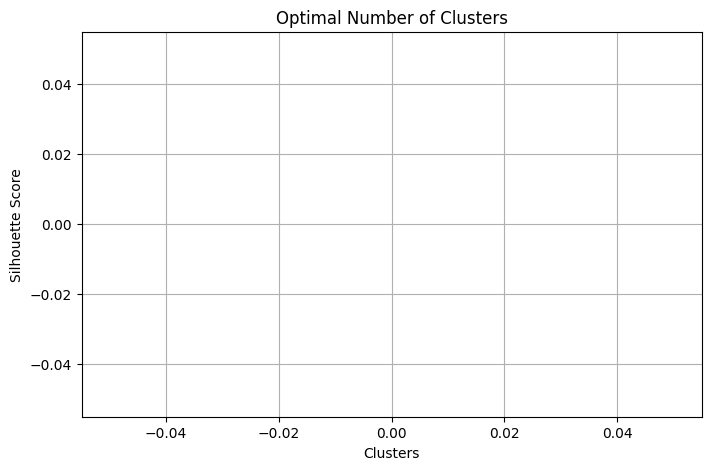

In [20]:
plt.figure(figsize=(8,5))

plt.plot(

    cluster_results["Clusters"],

    cluster_results["Silhouette"],

    marker="o"

)

plt.title("Optimal Number of Clusters")

plt.xlabel("Clusters")

plt.ylabel("Silhouette Score")

plt.grid()

plt.show()

In [21]:
joblib.dump(

    best_ridge,

    "../models/ridge_best.pkl"

)

joblib.dump(

    best_logistic,

    "../models/logistic_best.pkl"

)

['../models/logistic_best.pkl']

In [22]:
comparison = pd.DataFrame({

    "Model":[

        "Ridge Regression",

        "Logistic Regression"

    ],

    "Best Parameter":[

        ridge_grid.best_params_,

        logistic_grid.best_params_

    ],

    "Best Score":[

        ridge_score,

        accuracy

    ]

})

comparison

,Model,Best Parameter,Best Score
0,Ridge Regression,{'alpha': 5},0.963675
1,Logistic Regression,"{'C': 0.01, 'solver': 'lbfgs'}",0.877484


In [23]:
comparison.to_csv(

    "../reports/model_optimization.csv",

    index=False

)

cluster_results.to_csv(

    "../reports/kmeans_optimization.csv",

    index=False
)